In [1]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [2]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In this example, we use a 2D toy dataset consisting of:

- $\pi_0$: A standard 2D Gaussian distribution with mean of zeros and identity covariance matrix.
- $\pi_1$: A custom two-point Gaussian mixture model with centers located at $(15, 2)$ and $(15, -2)$ and a standard deviation of $0.3$

Generated 25000 samples from a low-rank Gaussian distribution.
Generated 25000 samples from a low-rank Gaussian distribution.


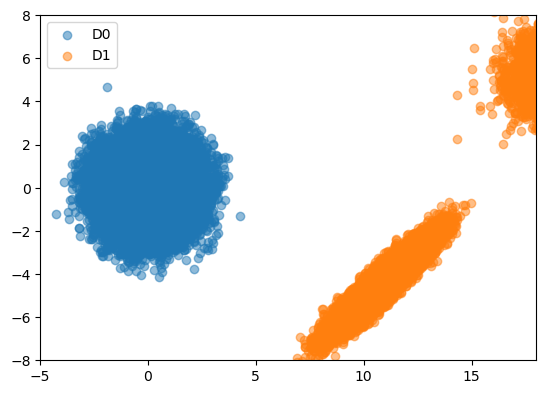

In [3]:
n_samples = 50000
INPUT_DIM = 2
CENTER1 = [20.0, 5.0]
CENTER2 = [10.0, -5.0]
pi_0 = dist.MultivariateNormal(torch.zeros(2, device=device), torch.eye(2, device=device))
#pi_1 = TwoPointGMM(x=15.0, y= 5, std=0.3)
pi_11 = gmm.LowrankGaussian(n_samples= int(n_samples/2), n_features=INPUT_DIM, rank= 2, random_state= 24)
pi_11.generate_data()
pi_12 = gmm.LowrankGaussian(n_samples=int(n_samples/2), n_features=INPUT_DIM, rank= 2, random_state=25)
pi_12.generate_data()
data1 = torch.tensor(pi_11.data, device=device, dtype=torch.float32) + torch.tensor(CENTER1, device=device, dtype=torch.float32)
data2 = torch.tensor(pi_12.data, device=device, dtype=torch.float32) + torch.tensor(CENTER2, device=device, dtype=torch.float32)
pi_1 = torch.cat([data1, data2], dim=0)

D0 = pi_0.sample([n_samples])   
D1 = pi_1
D0 = pi_0.sample([n_samples])
#D1, labels = pi_1.sample_with_labels([n_samples])
#labels.tolist()

plt.scatter(D0[:, 0].cpu().numpy(), D0[:, 1].cpu().numpy(), alpha=0.5, label='D0')
plt.scatter(D1[:, 0].cpu().numpy(), D1[:, 1].cpu().numpy(), alpha=0.5, label='D1')
plt.legend()
plt.xlim(-5, 18)
plt.ylim(-8, 8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [10]:
D0.shape, D1.shape

(torch.Size([50000, 2]), torch.Size([50000, 2]))

In [4]:
def rf_trainer(rectified_flow, label = 'loss', batch_size = 1024):
    model = rectified_flow.velocity_field
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = rectified_flow.get_loss

    losses = []

    num_epochs = 5000
    for epoch in range(num_epochs):
        idx = torch.randint(0, D0.shape[0], (batch_size,))
        x0_batch = D0[idx]
        x1_batch = D1[idx]

        loss = criterion(x0_batch, x1_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 500 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], {label}: {loss.item():.4f}')
    plt.plot(losses, label=label)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()

Epoch [1/5000], loss: 159.3147
Epoch [501/5000], loss: 6.8010
Epoch [1001/5000], loss: 5.4099
Epoch [1501/5000], loss: 5.8842
Epoch [2001/5000], loss: 5.1536
Epoch [2501/5000], loss: 5.1608
Epoch [3001/5000], loss: 5.6442
Epoch [3501/5000], loss: 5.9599
Epoch [4001/5000], loss: 5.3148
Epoch [4501/5000], loss: 5.7975


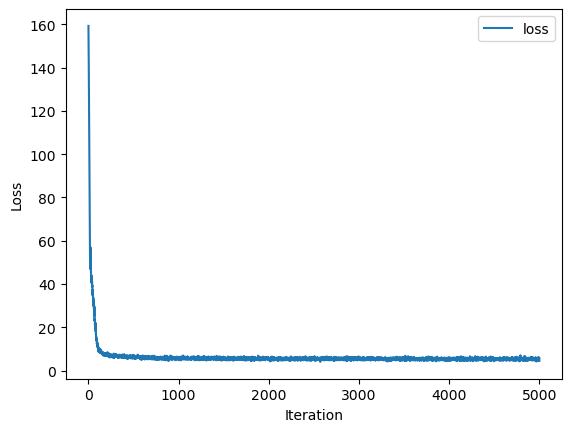

In [5]:
from rectified_flow.models.toy_mlp import MLPVelocity

straight_rf = RectifiedFlow(
    data_shape=(2,),
    velocity_field=MLPVelocity(2, hidden_sizes = [128, 128, 128]).to(device),
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

rf_trainer(straight_rf)

In [6]:
from rectified_flow.samplers.base_sampler import Sampler

class MyEulerSampler(Sampler):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def step(self, **model_kwargs):
        # Extract the current time, next time point, and current state
        t, t_next, x_t = self.t, self.t_next, self.x_t
        
        # Compute the velocity field at the current state and time
        v_t = self.rectified_flow.get_velocity(x_t=x_t, t=t, **model_kwargs)
        
        # Update the state using the Euler formula
        self.x_t = x_t + (t_next - t) * v_t
        

NUM_STEPS = 100
NUM_SAMPLES = 2000
euler_sampler = MyEulerSampler(
    rectified_flow=straight_rf,
    num_steps= NUM_STEPS,
    num_samples= NUM_SAMPLES,
)

# Sample method 1)
# Will use the default num_steps and num_samples previously set in the Sampler class
traj1 = euler_sampler.sample_loop(seed=100)

from rectified_flow.samplers import SDESampler

sde_sampler_sphere = SDESampler(
    rectified_flow=straight_rf,
	num_steps= NUM_STEPS,
	num_samples= NUM_SAMPLES,
    noise_scale = lambda t: 1/(t + 1e-6),
    noise_method = 'euler',
    ode_method = 'euler'
)
traj2 = sde_sampler_sphere.sample_loop(seed=100)

In [191]:
np.array(traj1.trajectories).shape, np.array(traj2.trajectories).shape

((101, 2000, 2), (101, 2000, 2))

In [7]:
# visualize the trajectories by tracing the trajectories
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
from matplotlib.lines import Line2D

def draw_plot_sns(traj, z1, M=5, num_traj = 100, sampler_label = 'Deterministic Sampler', save_pdf=True):
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.2
    )

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.set_xlim(-0.5*M, M)
    ax.set_ylim(-0.5*M, 0.5*M)

    # -------- prepare data --------
    p1 = z1[:900].cpu().numpy()
    p0 = traj[0].cpu().numpy()
    gen = traj[-1].cpu().numpy()

    df = pd.DataFrame(
        {
            "x": np.concatenate([p1[:, 0], p0[:, 0], gen[:, 0]]),
            "y": np.concatenate([p1[:, 1], p0[:, 1], gen[:, 1]]),
            "dist": (
                ["$p_1$"] * len(p1)
                + ["$p_0$"] * len(p0)
                + ["Generated"] * len(gen)
            ),
        }
    )

    # -------- seaborn scatter --------
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue="dist",
        alpha=0.35,
        s=20,
        ax=ax,
        legend=False
    )

    # -------- trajectories (matplotlib) --------
    traj_particles = torch.stack(traj).cpu().numpy()
    for i in range(min(num_traj, traj_particles.shape[1])):
        ax.plot(
            traj_particles[:, i, 0],
            traj_particles[:, i, 1],
            color="gray",
            alpha=0.15,
            linewidth=0.8
        )

    # -------- opaque legend --------
    palette = sns.color_palette()

    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_1$', markerfacecolor=palette[0], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_0$', markerfacecolor=palette[1], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label='Generated', markerfacecolor=palette[2], markersize=8),
    ]

    ax.legend(
        handles=legend_elements,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        loc="upper left"
    )

    ax.set_title(sampler_label, pad=8)
    ax.set_aspect("equal", adjustable="box")
    sns.despine(trim=True)
    plt.tight_layout()
    if save_pdf:
        plt.savefig(sampler_label.replace(" ", "_") + '.pdf', format='pdf', bbox_inches='tight', dpi = 300)
    


In [25]:
# nicer visualization of the trajectories
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde


def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def draw_plot_v2(
    traj,
    z1,
    M=5,
    num_traj=30,
    sampler_label="Deterministic (RF)",
    ax=None,
    score_fn=None,
    arrow_points=None,
    arrow_scale=0.5,
    density_threshold=None,
    save_path=None,
):
    """
    score_fn(points): accepts an (N, 2) NumPy array and returns
        the score / score-driven drift at the FINAL plotted time.
        Wrap your torch model if necessary.

    arrow_scale: display multiplier for arrows; use the same value
        across comparable figures.

    density_threshold: optional common target-KDE density threshold.
        Endpoints below it are highlighted. Use the SAME threshold
        and target samples for both samplers.
    """
    paths = np.stack([to_numpy(x) for x in traj])
    target = to_numpy(z1)
    initial, generated = paths[0], paths[-1]

    if ax is None:
        _, ax = plt.subplots(figsize=(5.2, 4.2))
    fig = ax.figure

    blue = "#4C91CB"
    teal = "#009E91"
    purple = "#8B45B5"
    red = "#D55E00"

    xlim = (-10, M)
    ylim = (-10, 10)

    # Target-density estimate: identical when z1 is identical.
    kde = gaussian_kde(target.T)
    xx, yy = np.meshgrid(
        np.linspace(*xlim, 240),
        np.linspace(*ylim, 240),
    )
    density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Relative density levels, not probability-mass contours.
    levels = density.max() * np.array([0.03, 0.10, 0.25, 0.50, 0.75])
    ax.contourf(
        xx, yy, density,
        levels=np.r_[levels, density.max() * 1.001],
        colors=["#DEEBF7", "#BDD7E7", "#8EC1DF", "#549ECD", "#2879B9"],
        alpha=0.95,
        zorder=0,
    )
    ax.contour(
        xx, yy, density,
        levels=levels,
        colors="#3577A8",
        linewidths=0.6,
        alpha=0.55,
        zorder=1,
    )

    # Evenly spaced particle indices; same selection for both samplers.
    count = min(num_traj, paths.shape[1])
    indices = np.linspace(0, paths.shape[1] - 1, count, dtype=int)
    for i in indices:
        ax.plot(
            paths[:, i, 0], paths[:, i, 1],
            color="#737B83", alpha=0.18, linewidth=0.65, zorder=2,
        )

    ax.scatter(
        initial[:, 0], initial[:, 1],
        s=9, color="#A5ABB1", alpha=0.35,
        edgecolors="none", zorder=3,
    )

    low_density = np.zeros(len(generated), dtype=bool)
    if density_threshold is not None:
        low_density = kde(generated.T) < density_threshold

    ax.scatter(
        generated[~low_density, 0], generated[~low_density, 1],
        s=10, color=teal, alpha=0.15,
        edgecolors="white", linewidths=0.2, zorder=4,
    )

    if low_density.any():
        ax.scatter(
            generated[low_density, 0], generated[low_density, 1],
            s=25, color=red, alpha=0.95,
            edgecolors="white", linewidths=0.4, zorder=5,
        )

    handles = [
        Line2D([], [], color=blue, lw=1.5, label="Target density"),
        Line2D([], [], marker="o", linestyle="", color="#A5ABB1",
               markersize=5, label="Initial samples"),
        Line2D([], [], marker="o", linestyle="", color=teal,
               markersize=5, label="Generated samples"),
    ]

    if density_threshold is not None:
        handles.append(
            Line2D([], [], marker="o", linestyle="", color=red,
                   markersize=5, label="Low-density endpoints")
        )

    # Actual score-driven direction; no artificial inward arrows.
    if score_fn is not None:
        if arrow_points is None:
            raise ValueError("Provide arrow_points for the score arrows.")
        points = np.asarray(arrow_points, dtype=float)
        vectors = to_numpy(score_fn(points))
        if vectors.shape != points.shape:
            raise ValueError("score_fn must return shape (N, 2).")

        ax.quiver(
            points[:, 0], points[:, 1],
            arrow_scale * vectors[:, 0],
            arrow_scale * vectors[:, 1],
            angles="xy", scale_units="xy", scale=1,
            color=purple, width=0.006,
            headwidth=4, headlength=5, zorder=6,
        )
        handles.append(
            Line2D([], [], color=purple, lw=2,
                   label="Score drift (scaled)")
        )

    ax.set(
        xlim=xlim, ylim=ylim,
        xlabel="$x$", ylabel="$y$",
        title=sampler_label,
    )
    # ax.set_aspect("equal", adjustable="box")
    ax.set_aspect(1.4, adjustable="box")  # Squeeze horizontally
    ax.set_xlim(-5, 28)                  # Trim empty horizontal space
    ax.set_facecolor("white")
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#A5ABB1")
    ax.tick_params(labelsize=9, color="#A5ABB1")
    ax.title.set_fontsize(12)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, ax, handles

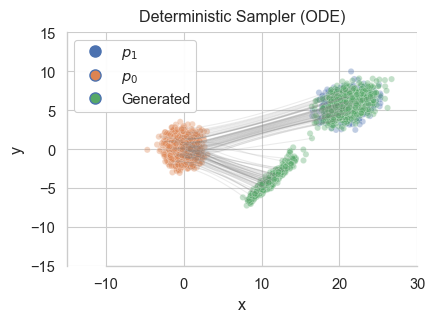

In [ ]:
fig = draw_plot_sns(traj1.trajectories, D1, M=30, num_traj=100,
                     sampler_label='Deterministic Sampler (ODE)', save_pdf=False)
# save as pdf




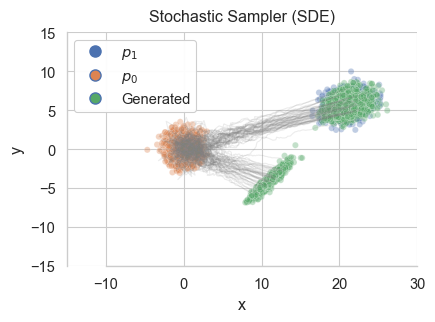

In [9]:
draw_plot_sns(traj2.trajectories, D1, M=30, num_traj=100, sampler_label='Stochastic Sampler (SDE)', save_pdf = False)

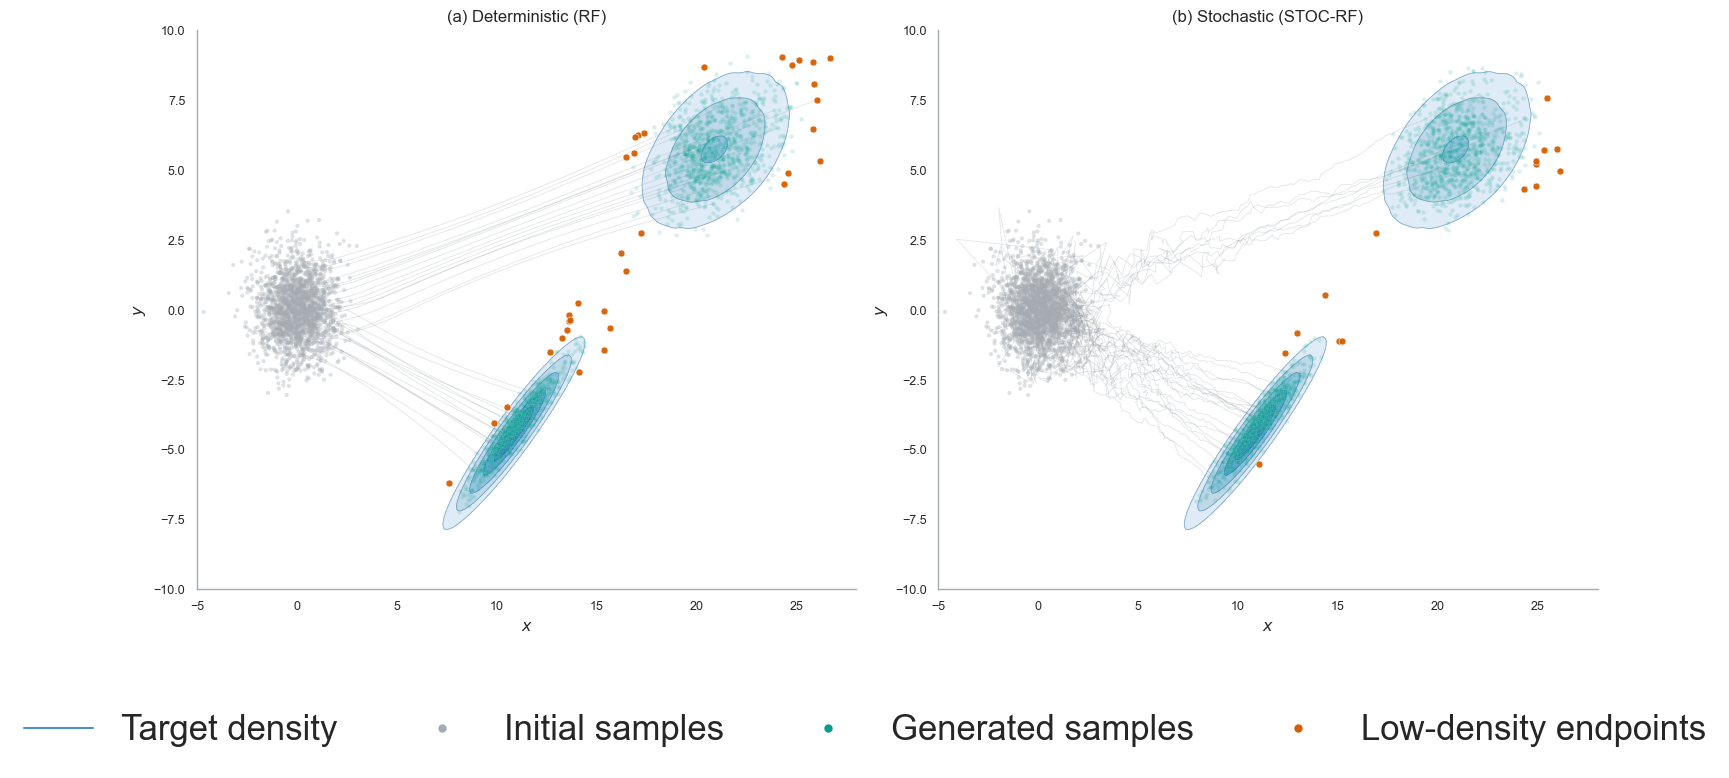

In [27]:
# Replace these with your trajectory lists.
traj_ode = traj1.trajectories
traj_sde = traj2.trajectories

fig, axes = plt.subplots(1, 2, figsize=(15, 8.5))

# Optional illustrative criterion: the density cutoff below which
# 1% of reference target samples fall. This is NOT a formal OOD test.
# Prefer held-out target samples for calibrating a reported metric.
target = to_numpy(D1)
target_kde = gaussian_kde(target.T)
threshold = np.quantile(target_kde(target.T), 0.01)


for ax, paths, title in zip(
    axes,
    [traj_ode, traj_sde],
    ["(a) Deterministic (RF)", "(b) Stochastic (STOC-RF)"],
):
    _, _, handles = draw_plot_v2(
        paths,
        D1,
        M=30,  # Match the coordinate range of your original figures.
        ax=ax,
        sampler_label=title,
        density_threshold=threshold,
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=25,
)
fig.tight_layout(rect=(0, 0.12, 1, 1))
#fig.savefig("sampler_comparison.pdf", bbox_inches="tight")
#fig.savefig("sampler_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

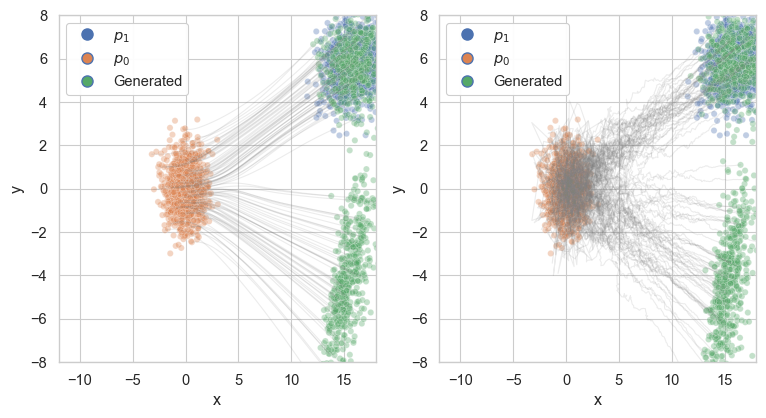

In [153]:
# side-by-side comparison
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)       
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5)) 
for ax, traj, sampler_label in zip(axs, [traj1.trajectories, traj2.trajectories], ['Deterministic Sampler (ODE)', 'Stochastic Sampler (SDE)']):
    ax.set_xlim(-12, 18)
    ax.set_ylim(-8, 8)

    # -------- prepare data --------
    p1 = D1[:900].cpu().numpy()
    p0 = traj[0].cpu().numpy()
    gen = traj[-1].cpu().numpy()

    df = pd.DataFrame(
        {
            "x": np.concatenate([p1[:, 0], p0[:, 0], gen[:, 0]]),
            "y": np.concatenate([p1[:, 1], p0[:, 1], gen[:, 1]]),
            "dist": (
                ["$p_1$"] * len(p1)
                + ["$p_0$"] * len(p0)
                + ["Generated"] * len(gen)
            ),
        }
    )

    # -------- seaborn scatter --------
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue="dist",
        alpha=0.35,
        s=20,
        ax=ax,
        legend=False
    )

    # -------- trajectories (matplotlib) --------
    traj_particles = torch.stack(traj).cpu().numpy()
    for i in range(min(100, traj_particles.shape[1])):
        ax.plot(
            traj_particles[:, i, 0],
            traj_particles[:, i, 1],
            color="gray",
            alpha=0.15,
            linewidth=0.8
        )

    # -------- opaque legend --------
    palette = sns.color_palette()

    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_1$', markerfacecolor=palette[0], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_0$', markerfacecolor=palette[1], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label='Generated', markerfacecolor=palette[2], markersize=8),
    ]

    ax.legend(
        handles=legend_elements,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        loc="upper left"
    )